In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("/content/WineQT.csv")

print(df.head())

print(df.shape)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \

In [ ]:
df.drop('Id', axis=1, inplace=True)

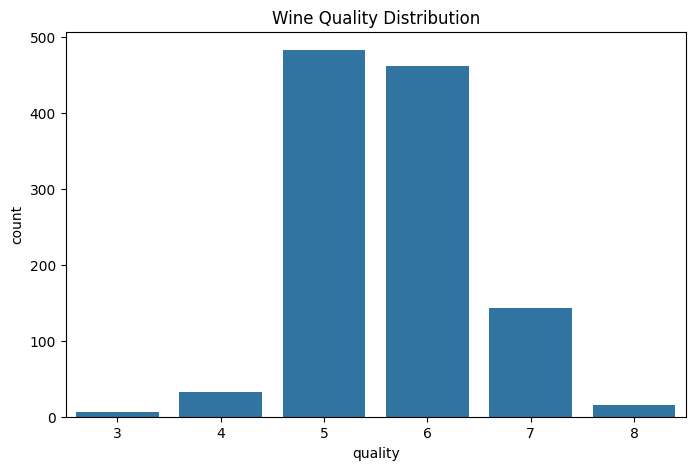

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=df
)

plt.title("Wine Quality Distribution")

plt.show()

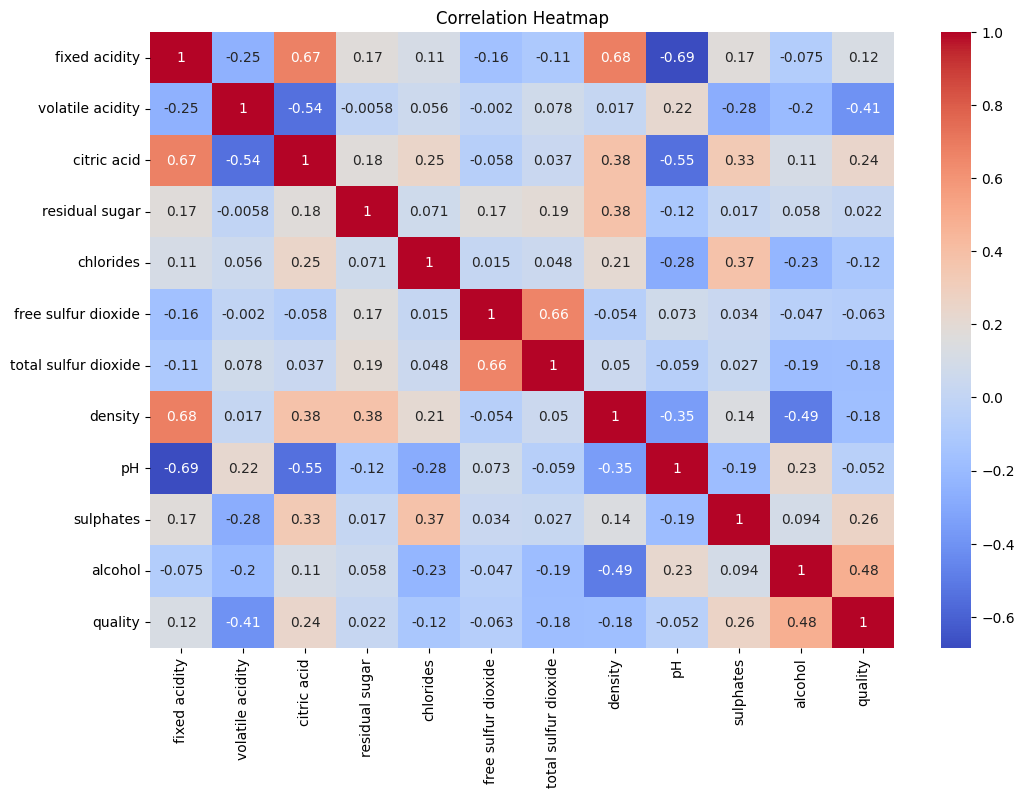

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
df['quality'] = df['quality'].apply(
    lambda x: 1 if x >= 7 else 0
)

In [ ]:
X = df.drop('quality', axis=1)

y = df['quality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      rf_acc)

Random Forest Accuracy: 0.9170305676855895


In [ ]:
sgd = SGDClassifier(
    random_state=42
)

sgd.fit(
    X_train,
    y_train
)

sgd_pred = sgd.predict(X_test)

sgd_acc = accuracy_score(
    y_test,
    sgd_pred
)

print("SGD Accuracy:",
      sgd_acc)

SGD Accuracy: 0.868995633187773


In [ ]:
svc = SVC()

svc.fit(
    X_train,
    y_train
)

svc_pred = svc.predict(X_test)

svc_acc = accuracy_score(
    y_test,
    svc_pred
)

print("SVC Accuracy:",
      svc_acc)

SVC Accuracy: 0.8908296943231441


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD',
        'SVC'
    ],
    'Accuracy': [
        rf_acc,
        sgd_acc,
        svc_acc
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.917031
1            SGD  0.868996
2            SVC  0.890830


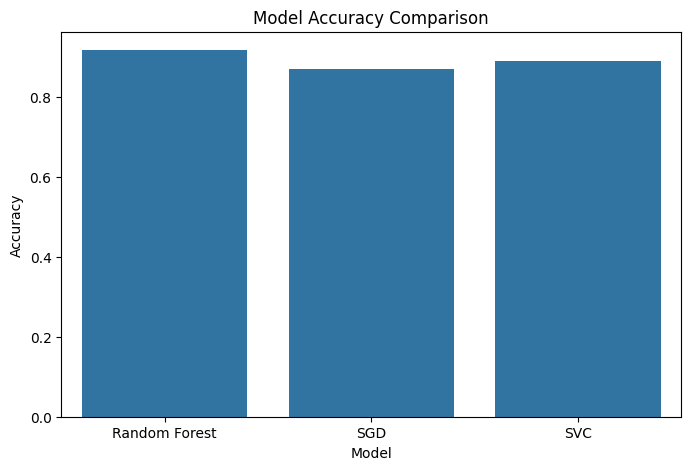

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       201
           1       0.70      0.57      0.63        28

    accuracy                           0.92       229
   macro avg       0.82      0.77      0.79       229
weighted avg       0.91      0.92      0.91       229



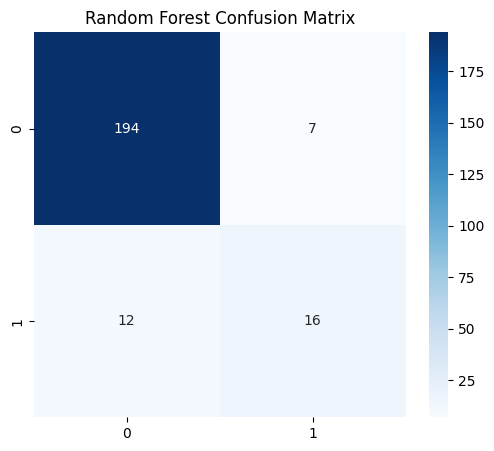

In [ ]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.163982
9              sulphates    0.120266
1       volatile acidity    0.112545
7                density    0.103119
2            citric acid    0.086050
0          fixed acidity    0.077569
4              chlorides    0.073959
6   total sulfur dioxide    0.072437
8                     pH    0.067294
3         residual sugar    0.065264
5    free sulfur dioxide    0.057516


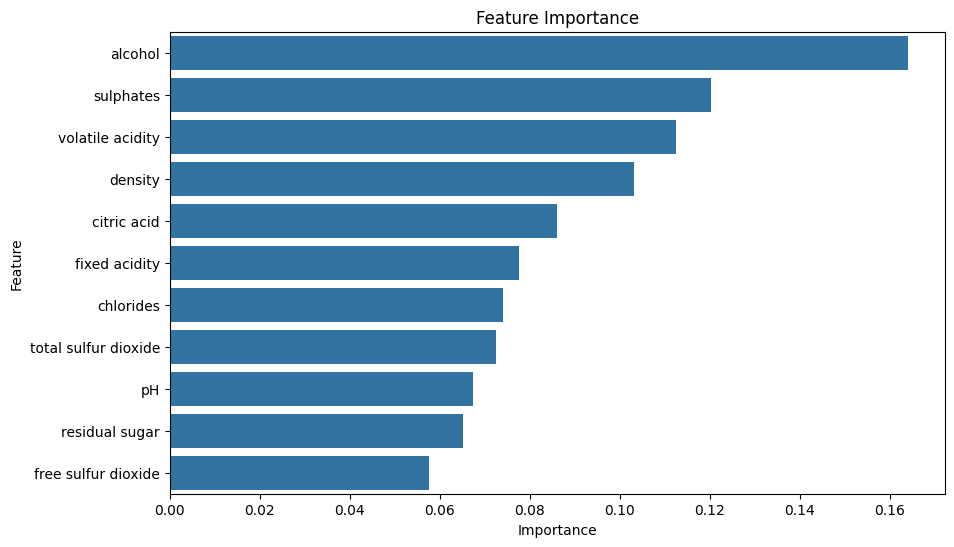

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()